<a href="https://colab.research.google.com/github/j5675293/DESAFIOS__NPL_1/blob/NPL_1/DESAFIO_4_NLP__1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DESAFIO 4
## CARRERA DE ESPECIALIDAD EN INTELIGENCIA ARTIFICIAL - FIUBA
### JUAN RUIZ OTONDO
#### a1702

# Procesamiento de lenguaje natural
## LSTM Bot QA
### Datos
El objecto es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder a preguntas del usuario (QA).

In [ ]:
# https://convai.io/data/
# https://github.com/DeepPavlovAdmin/convai

2 - Preprocesamiento
Realizar el preprocesamiento necesario para obtener:

word2idx_inputs, max_input_len
word2idx_outputs, max_out_len, num_words_output
encoder_input_sequences, decoder_output_sequences, decoder_targets.

3 - Preparar los embeddings
Utilizar los embeddings de Glove o FastText para transformar los tokens de entrada en vectores

4 - Entrenar el modelo
Entrenar un modelo basado en el esquema encoder-decoder utilizando los datos generados en los puntos anteriores. Utilce como referencias los ejemplos vistos en clase.

5 - Inferencia
Experimentar el funcionamiento de su modelo. Recuerde que debe realizar la inferencia de los modelos por separado de encoder y decoder.

# DIAGNOSTICO DE DESCARGA DE DATASET PARA ENTRENAMIENTO

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("danielwillgeorge/glove6b100dtxt")

print("Path to dataset files:", path)

100%|██████████| 131M/131M [00:00<00:00, 191MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/danielwillgeorge/glove6b100dtxt/versions/1


In [ ]:
import kagglehub

# Descarga la última versión del dataset
path = kagglehub.dataset_download("danielwillgeorge/glove6b100dtxt")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/glove6b100dtxt


In [ ]:
# Construye la ruta completa al archivo glove.6B.100d.txt
glove_file_path = os.path.join(path, "glove.6B.100d.txt")

print(f"\nIntentando verificar la existencia de: {glove_file_path}")

if os.path.exists(glove_file_path):
    print(f"✅ ¡Excelente! El archivo '{glove_file_path}' **existe** en tu entorno de Colab.")
    print("Ahora puedes cargarlo y usarlo en tu código.")
    # Ejemplo de cómo podrías empezar a usarlo:
    # with open(glove_file_path, 'r', encoding='utf-8') as f:
    #     first_line = f.readline()
    #     print(f"\nPrimera línea del archivo: {first_line.strip()}...")
else:
    print(f"❌ Lo siento, el archivo '{glove_file_path}' **NO existe** en la ruta especificada.")
    print("Por favor, revisa que la ruta 'path' sea la correcta o que la descarga se haya completado exitosamente.")


Intentando verificar la existencia de: /kaggle/input/glove6b100dtxt/glove.6B.100d.txt
✅ ¡Excelente! El archivo '/kaggle/input/glove6b100dtxt/glove.6B.100d.txt' **existe** en tu entorno de Colab.
Ahora puedes cargarlo y usarlo en tu código.


In [ ]:
import kagglehub
import os

# --- 1. Descarga el dataset usando kagglehub ---
print("Iniciando la descarga del dataset GloVe...")
path = kagglehub.dataset_download("danielwillgeorge/glove6b100dtxt")
print("Descarga completada.")
print(f"Ruta al directorio del dataset: {path}\n")

# --- 2. Construye la ruta completa al archivo glove.6B.100d.txt ---
glove_file_path = os.path.join(path, "glove.6B.100d.txt")

# --- 3. Verifica si el archivo existe ---
print(f"Verificando la existencia del archivo: {glove_file_path}")
if os.path.exists(glove_file_path):
    print(f"✅ ¡El archivo '{glove_file_path}' existe en tu entorno de Colab!")

    # --- 4. Imprime información técnica del archivo GloVe ---
    print("\n--- Información Técnica del Archivo GloVe ---")
    num_words = 0
    vector_dimension = 0

    try:
        with open(glove_file_path, 'r', encoding='utf-8') as f:
            for i, line in enumerate(f):
                if i == 0:  # Solo necesitamos la primera línea para la dimensión
                    parts = line.strip().split(' ')
                    # La primera parte es la palabra, el resto son los valores del vector
                    vector_dimension = len(parts) - 1
                num_words += 1

        print(f"1. Cantidad de palabras (vocabulario): **{num_words}**")
        print(f"2. Dimensión de cada vector de palabra: **{vector_dimension}**")
        # Para el tamaño del archivo, usamos os.path.getsize()
        file_size_bytes = os.path.getsize(glove_file_path)
        print(f"3. Tamaño del archivo: **{file_size_bytes / (1024 * 1024):.2f} MB**")
        print("-" * 40)

    except Exception as e:
        print(f"❌ Ocurrió un error al leer el archivo GloVe: {e}")
else:
    print(f"❌ Error: El archivo '{glove_file_path}' NO se encontró.")
    print("Asegúrate de que la descarga de KaggleHub se completó correctamente.")

Iniciando la descarga del dataset GloVe...
Descarga completada.
Ruta al directorio del dataset: /kaggle/input/glove6b100dtxt

Verificando la existencia del archivo: /kaggle/input/glove6b100dtxt/glove.6B.100d.txt
✅ ¡El archivo '/kaggle/input/glove6b100dtxt/glove.6B.100d.txt' existe en tu entorno de Colab!

--- Información Técnica del Archivo GloVe ---
1. Cantidad de palabras (vocabulario): **400000**
2. Dimensión de cada vector de palabra: **100**
3. Tamaño del archivo: **331.04 MB**
----------------------------------------


# INICIO DE MODELACIÓN LSTM Bot QA

In [ ]:
# ==================== INSTALACIÓN DE DEPENDENCIAS ====================
!pip install kagglehub gdown tensorflow numpy pandas matplotlib


In [ ]:
# ==================== IMPORTS ====================
import os
import re
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import kagglehub
import gdown
from collections import Counter
import pickle

In [ ]:
# ==========================================
# 1. DESCARGA Y CARGA DEL DATASET
# ==========================================

In [ ]:
print("=== DESCARGANDO DATASETS ===")

=== DESCARGANDO DATASETS ===


In [ ]:
# Descarga dataset ConvAI2
if not os.path.exists('data_volunteers.json'):
    url = 'https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download'
    output = 'data_volunteers.json'
    gdown.download(url, output, quiet=False)
    print("Dataset ConvAI2 descargado")
else:
    print("Dataset ConvAI2 ya existe")

# Descarga GloVe embeddings
try:
    path = kagglehub.dataset_download("danielwillgeorge/glove6b100dtxt")
    print(f"Path to GloVe dataset: {path}")
    glove_path = path
except:
    print("Error descargando GloVe, usando embeddings aleatorios")
    glove_path = None

# Carga datos ConvAI2
with open('data_volunteers.json', 'r') as f:
    data = json.load(f)

print(f"Datos cargados: {len(data)} conversaciones")
print(f"Campos disponibles: {list(data[0].keys())}")

Downloading...
From: https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download
To: /content/data_volunteers.json
100%|██████████| 2.58M/2.58M [00:00<00:00, 24.0MB/s]


Dataset ConvAI2 descargado


100%|██████████| 131M/131M [00:00<00:00, 157MB/s]

Extracting files...


Path to GloVe dataset: /root/.cache/kagglehub/datasets/danielwillgeorge/glove6b100dtxt/versions/1
Datos cargados: 1111 conversaciones
Campos disponibles: ['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id']


In [ ]:
# ==========================================
# 2. PREPROCESAMIENTO DE DATOS
# ==========================================

In [ ]:
print("\n=== PREPROCESAMIENTO ===")


=== PREPROCESAMIENTO ===


In [ ]:
def clean_text(txt):
    """Limpia y normaliza el texto"""
    if not isinstance(txt, str):
        return ""

    txt = txt.lower()
    # Expandir contracciones
    contractions = {
        "'d": " had", "'s": " is", "'m": " am", "'re": " are",
        "'ll": " will", "'ve": " have", "don't": "do not",
        "won't": "will not", "can't": "cannot", "n't": " not"
    }

    for contraction, expansion in contractions.items():
        txt = txt.replace(contraction, expansion)

    # Mantiene solo letras, números y espacios
    txt = re.sub(r'[^a-zA-Z0-9\s]', '', txt)
    # Elimina espacios extra
    txt = re.sub(r'\s+', ' ', txt).strip()

    return txt

# Extrae pares de conversación
input_sentences = []
output_sentences = []
max_len = 50  # Aumentamos un poco el límite

print("Extrayendo pares de conversación...")
for conversation in data:
    dialog = conversation.get('dialog', [])
    for i in range(len(dialog) - 1):
        input_text = clean_text(dialog[i].get('text', ''))
        output_text = clean_text(dialog[i + 1].get('text', ''))

        # Filtrar textos muy largos o muy cortos
        if (len(input_text.split()) <= max_len and
            len(output_text.split()) <= max_len and
            len(input_text.split()) >= 2 and
            len(output_text.split()) >= 2):

            input_sentences.append(input_text)
            output_sentences.append(output_text)

print(f"Pares de conversación extraídos: {len(input_sentences)}")

# Limitar dataset para entrenamiento más rápido en Colab
MAX_SAMPLES = 10000
if len(input_sentences) > MAX_SAMPLES:
    input_sentences = input_sentences[:MAX_SAMPLES]
    output_sentences = output_sentences[:MAX_SAMPLES]
    print(f"Dataset limitado a {MAX_SAMPLES} muestras para entrenamiento")

# Agregar tokens especiales a las respuestas
output_sentences_with_tokens = ['<START> ' + sentence + ' <END>' for sentence in output_sentences]


Extrayendo pares de conversación...
Pares de conversación extraídos: 9839


In [ ]:
# ==========================================
# 3. TOKENIZACIÓN
# ==========================================

In [ ]:
print("\n=== TOKENIZACIÓN ===")


=== TOKENIZACIÓN ===


In [ ]:
# Tokeniza inputs
input_tokenizer = Tokenizer(filters='', lower=True)
input_tokenizer.fit_on_texts(input_sentences)
input_sequences = input_tokenizer.texts_to_sequences(input_sentences)

# Tokeniza outputs
output_tokenizer = Tokenizer(filters='', lower=True)
output_tokenizer.fit_on_texts(output_sentences_with_tokens)
output_sequences = output_tokenizer.texts_to_sequences(output_sentences_with_tokens)

# Vocabularios
word2idx_inputs = input_tokenizer.word_index
word2idx_outputs = output_tokenizer.word_index
idx2word_inputs = {v: k for k, v in word2idx_inputs.items()}
idx2word_outputs = {v: k for k, v in word2idx_outputs.items()}

num_words_input = len(word2idx_inputs) + 1
num_words_output = len(word2idx_outputs) + 1

print(f"Vocabulario input: {num_words_input} palabras")
print(f"Vocabulario output: {num_words_output} palabras")

# Longitudes máximas
max_input_len = max(len(seq) for seq in input_sequences)
max_output_len = max(len(seq) for seq in output_sequences)

print(f"Longitud máxima input: {max_input_len}")
print(f"Longitud máxima output: {max_output_len}")

# Padding de secuencias
encoder_input_sequences = pad_sequences(input_sequences, maxlen=max_input_len, padding='post')

# Para el decoder, necesitamos input y target
decoder_input_sequences = pad_sequences(output_sequences, maxlen=max_output_len, padding='post')
decoder_target_sequences = np.zeros_like(decoder_input_sequences)
decoder_target_sequences[:, :-1] = decoder_input_sequences[:, 1:]

print(f"Forma encoder_input_sequences: {encoder_input_sequences.shape}")
print(f"Forma decoder_input_sequences: {decoder_input_sequences.shape}")
print(f"Forma decoder_target_sequences: {decoder_target_sequences.shape}")

Vocabulario input: 3611 palabras
Vocabulario output: 3582 palabras
Longitud máxima input: 40
Longitud máxima output: 44
Forma encoder_input_sequences: (9839, 40)
Forma decoder_input_sequences: (9839, 44)
Forma decoder_target_sequences: (9839, 44)


In [ ]:
# ==========================================
# 4. PREPARAR EMBEDDINGS
# ==========================================

In [ ]:
print("\n=== PREPARANDO EMBEDDINGS ===")


=== PREPARANDO EMBEDDINGS ===


In [ ]:
EMBEDDING_DIM = 100

def load_glove_embeddings(glove_path, word_index, embedding_dim):
    """Carga embeddings GloVe"""
    embeddings_index = {}

    if glove_path is None:
        print("Usando embeddings aleatorios")
        return None

    try:
        # Busca archivo GloVe
        glove_file = None
        for root, dirs, files in os.walk(glove_path):
            for file in files:
                if file.endswith('.txt') and '100d' in file:
                    glove_file = os.path.join(root, file)
                    break
            if glove_file:
                break

        if not glove_file:
            print("Archivo GloVe no encontrado, usando embeddings aleatorios")
            return None

        print(f"Cargando embeddings desde: {glove_file}")

        with open(glove_file, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                vector = np.asarray(values[1:], dtype='float32')
                if len(vector) == embedding_dim:
                    embeddings_index[word] = vector

        print(f"Embeddings GloVe cargados: {len(embeddings_index)} palabras")

        # Crea matriz de embeddings
        vocab_size = len(word_index) + 1
        embedding_matrix = np.zeros((vocab_size, embedding_dim))

        found = 0
        for word, idx in word_index.items():
            if word in embeddings_index:
                embedding_matrix[idx] = embeddings_index[word]
                found += 1
            else:
                # Inicialización aleatoria para palabras no encontradas
                embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)

        print(f"Palabras encontradas en GloVe: {found}/{len(word_index)}")
        return embedding_matrix

    except Exception as e:
        print(f"Error cargando GloVe: {e}")
        return None

# Carga embeddings para inputs
input_embedding_matrix = load_glove_embeddings(glove_path, word2idx_inputs, EMBEDDING_DIM)

# Carga embeddings para outputs (o usar aleatorios)
output_embedding_matrix = load_glove_embeddings(glove_path, word2idx_outputs, EMBEDDING_DIM)


Cargando embeddings desde: /root/.cache/kagglehub/datasets/danielwillgeorge/glove6b100dtxt/versions/1/glove.6B.100d.txt
Embeddings GloVe cargados: 400000 palabras
Palabras encontradas en GloVe: 3311/3610
Cargando embeddings desde: /root/.cache/kagglehub/datasets/danielwillgeorge/glove6b100dtxt/versions/1/glove.6B.100d.txt
Embeddings GloVe cargados: 400000 palabras
Palabras encontradas en GloVe: 3286/3581


In [ ]:
# ==========================================
# 4. MODELO ENCODER-DECODER
# ==========================================

In [ ]:
print("\n=== CONSTRUYENDO MODELO ===")


=== CONSTRUYENDO MODELO ===


In [ ]:
LATENT_DIM = 256
BATCH_SIZE = 32  # Reducido para mejor generalización
EPOCHS = 5      # Reducido por que demora el entrenamiento
DROPOUT_RATE = 0.3  # Agregar dropout para evitar overfitting

# Encoder mejorado
encoder_inputs = Input(shape=(max_input_len,), name='encoder_inputs')

if input_embedding_matrix is not None:
    encoder_embedding = Embedding(
        num_words_input, EMBEDDING_DIM,
        weights=[input_embedding_matrix],
        input_length=max_input_len,
        trainable=True,  # Permitir ajuste fino
        name='encoder_embedding'
    )(encoder_inputs)
else:
    encoder_embedding = Embedding(
        num_words_input, EMBEDDING_DIM,
        input_length=max_input_len,
        name='encoder_embedding'
    )(encoder_inputs)

# LSTM bidireccional para mejor comprensión
from tensorflow.keras.layers import Bidirectional, Dropout

encoder_lstm = Bidirectional(
    LSTM(LATENT_DIM//2, return_state=True, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
    name='encoder_lstm'
)
encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder_lstm(encoder_embedding)

# Combina estados forward y backward
state_h = tf.keras.layers.Concatenate()([forward_h, backward_h])
state_c = tf.keras.layers.Concatenate()([forward_c, backward_c])
encoder_states = [state_h, state_c]

# Decoder mejorado
decoder_inputs = Input(shape=(max_output_len,), name='decoder_inputs')

if output_embedding_matrix is not None:
    decoder_embedding = Embedding(
        num_words_output, EMBEDDING_DIM,
        weights=[output_embedding_matrix],
        input_length=max_output_len,
        trainable=True,  # Permitir ajuste fino
        name='decoder_embedding'
    )(decoder_inputs)
else:
    decoder_embedding = Embedding(
        num_words_output, EMBEDDING_DIM,
        input_length=max_output_len,
        name='decoder_embedding'
    )(decoder_inputs)

decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    dropout=DROPOUT_RATE,
    recurrent_dropout=DROPOUT_RATE,
    name='decoder_lstm'
)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

# Capa densa con dropout
decoder_dropout = Dropout(DROPOUT_RATE)(decoder_outputs)
decoder_dense = Dense(num_words_output, activation='softmax', name='decoder_dense')
decoder_outputs = decoder_dense(decoder_dropout)

# Modelo completo
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# Compila con learning rate más bajo para mejor convergencia
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001)  # Learning rate más conservador

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 40, 100)   │    361,100 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 44)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm        │ [(None, 256),     │    234,496 │ encoder_embeddin… │
│ (Bidirectional)     │ (None, 128),      │            │                   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 44, 100)   │    358,200 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ encoder_lstm[0][… │
│ (Concatenate)       │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256)       │          0 │ encoder_lstm[0][… │
│ (Concatenate)       │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 44, 256), │    365,568 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ concatenate[0][0… │
│                     │ (None, 256)]      │            │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 44, 256)   │          0 │ decoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 44, 3582)  │    920,574 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,239,938 (8.54 MB)

 Trainable params: 2,239,938 (8.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==========================================
# 5. ENTRENAMIENTO DE MODELO
# ==========================================

In [ ]:
print("\n=== ENTRENANDO MODELO ===")


=== ENTRENANDO MODELO ===


In [ ]:
# Callbacks mejorados
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    'best_chatbot_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

# Parada temprana si no mejora
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Reduce learning rate si se estanca
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.0001
)

# Divide datos en entrenamiento y validación
split_idx = int(0.8 * len(encoder_input_sequences))

train_encoder_inputs = encoder_input_sequences[:split_idx]
train_decoder_inputs = decoder_input_sequences[:split_idx]
train_decoder_targets = decoder_target_sequences[:split_idx]

val_encoder_inputs = encoder_input_sequences[split_idx:]
val_decoder_inputs = decoder_input_sequences[split_idx:]
val_decoder_targets = decoder_target_sequences[split_idx:]

print(f"Datos de entrenamiento: {len(train_encoder_inputs)}")
print(f"Datos de validación: {len(val_encoder_inputs)}")

# Verifica que no haya problemas con los datos
print("\n=== DIAGNÓSTICO DE DATOS ===")
print(f"Tokens únicos en outputs: {len(set(train_decoder_targets.flatten()))}")
print(f"Token más frecuente en targets: {np.bincount(train_decoder_targets.flatten()).argmax()}")

# Muestra algunos ejemplos de entrenamiento
print("\nEjemplos de entrenamiento:")
for i in range(min(3, len(train_encoder_inputs))):
    input_words = [idx2word_inputs.get(idx, '<UNK>') for idx in train_encoder_inputs[i] if idx != 0]
    output_words = [idx2word_outputs.get(idx, '<UNK>') for idx in train_decoder_inputs[i] if idx != 0]
    print(f"Input: {' '.join(input_words)}")
    print(f"Output: {' '.join(output_words)}")
    print("-" * 30)

# Entrena modelo con callbacks mejorados
history = model.fit(
    [train_encoder_inputs, train_decoder_inputs],
    train_decoder_targets,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=([val_encoder_inputs, val_decoder_inputs], val_decoder_targets),
    callbacks=[checkpoint, early_stopping, reduce_lr],
    verbose=1
)

# Guarda modelo final
model.save('final_chatbot_model.h5')

print(f"\n=== ENTRENAMIENTO COMPLETADO ===")
print(f"Épocas entrenadas: {len(history.history['loss'])}")
print(f"Mejor val_loss: {min(history.history['val_loss']):.4f}")
print(f"Mejor val_accuracy: {max(history.history['val_accuracy']):.4f}")

Datos de entrenamiento: 7871
Datos de validación: 1968

=== DIAGNÓSTICO DE DATOS ===
Tokens únicos en outputs: 3156
Token más frecuente en targets: 0

Ejemplos de entrenamiento:
Input: hi how are you
Output: <start> not bad and you <end>
------------------------------
Input: not bad and you
Output: <start> i am doing well just got engaged to my high school sweetheart <end>
------------------------------
Input: i am doing well just got engaged to my high school sweetheart
Output: <start> wowowowow congratulations is she pretty <end>
------------------------------
Epoch 1/5
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 929ms/step - accuracy: 0.8057 - loss: 2.2139

246/246 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.8058 - loss: 2.2100 - val_accuracy: 0.8664 - val_loss: 0.8199 - learning_rate: 0.0010
Epoch 2/5
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8620 - loss: 0.8173

246/246 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.8621 - loss: 0.8172 - val_accuracy: 0.8780 - val_loss: 0.7400 - learning_rate: 0.0010
Epoch 3/5
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 932ms/step - accuracy: 0.8723 - loss: 0.7333

246/246 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.8723 - loss: 0.7332 - val_accuracy: 0.8856 - val_loss: 0.6961 - learning_rate: 0.0010
Epoch 4/5
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 956ms/step - accuracy: 0.8786 - loss: 0.6878

246/246 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.8786 - loss: 0.6877 - val_accuracy: 0.8893 - val_loss: 0.6707 - learning_rate: 0.0010
Epoch 5/5
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 940ms/step - accuracy: 0.8825 - loss: 0.6506

246/246 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.8825 - loss: 0.6506 - val_accuracy: 0.8907 - val_loss: 0.6513 - learning_rate: 0.0010



=== ENTRENAMIENTO COMPLETADO ===
Épocas entrenadas: 5
Mejor val_loss: 0.6513
Mejor val_accuracy: 0.8907


In [ ]:
# ==========================================
# 5. MODELOS DE INFERENCIA
# ==========================================

In [ ]:
print("\n=== CREANDO MODELOS DE INFERENCIA ===")


=== CREANDO MODELOS DE INFERENCIA ===


In [ ]:
# Modelo encoder para inferencia
encoder_model = Model(encoder_inputs, encoder_states)

# Modelo decoder para inferencia
decoder_state_input_h = Input(shape=(LATENT_DIM,))
decoder_state_input_c = Input(shape=(LATENT_DIM,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_embedding_inf = decoder_embedding
decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(
    decoder_embedding_inf, initial_state=decoder_states_inputs
)
decoder_states_inf = [state_h_inf, state_c_inf]
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs_inf] + decoder_states_inf
)

# Guarda modelos de inferencia
encoder_model.save('encoder_model.h5')
decoder_model.save('decoder_model.h5')

# Guarda tokenizers
with open('input_tokenizer.pkl', 'wb') as f:
    pickle.dump(input_tokenizer, f)

with open('output_tokenizer.pkl', 'wb') as f:
    pickle.dump(output_tokenizer, f)

print("Modelos de inferencia guardados")

Modelos de inferencia guardados


In [ ]:
# ==========================================
# 6. FUNCIONES DE INFERENCIA OPTIMIZADA
# ==========================================

In [ ]:
def decode_sequence_improved(input_seq, encoder_model, decoder_model, output_tokenizer, max_output_len, temperature=0.7):
    """Decodifica una secuencia con muestreo mejorado para evitar repeticiones"""

    # Codifica la secuencia de entrada
    states_value = encoder_model.predict(input_seq, verbose=0)

    # Crea mapeo inverso de índices a palabras
    idx2word = {v: k for k, v in output_tokenizer.word_index.items()}

    # Genera secuencia de salida vacía
    target_seq = np.zeros((1, 1))

    # Token de inicio
    start_token_idx = output_tokenizer.word_index.get('<START>', 1)
    target_seq[0, 0] = start_token_idx

    decoded_sentence = []
    max_iterations = min(max_output_len, 15)

    for iteration in range(max_iterations):
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)

        # Aplica temperatura para diversidad
        predictions = output_tokens[0, -1, :] / temperature
        predictions = np.exp(predictions) / np.sum(np.exp(predictions))

        # Muestreo con probabilidades (no siempre el más probable)
        if iteration < 3:  # Primeras palabras más conservadoras
            sampled_token_index = np.argmax(predictions)
        else:  # Después más diverso
            # Top-k sampling para evitar tokens muy raros
            top_k = 10
            top_indices = np.argpartition(predictions, -top_k)[-top_k:]
            top_probs = predictions[top_indices]
            top_probs = top_probs / np.sum(top_probs)
            sampled_token_index = np.random.choice(top_indices, p=top_probs)

        sampled_token = idx2word.get(sampled_token_index, '<UNK>')

        # Condiciones de parada
        if sampled_token in ['<END>', '<UNK>'] or sampled_token_index == 0:
            break

        if sampled_token != '<START>':
            # Evita repeticiones inmediatas
            if len(decoded_sentence) > 0 and sampled_token == decoded_sentence[-1]:
                # Intenta el segundo token más probable
                predictions[sampled_token_index] = 0  # Eliminar el repetido
                sampled_token_index = np.argmax(predictions)
                sampled_token = idx2word.get(sampled_token_index, '<UNK>')

            if sampled_token not in ['<END>', '<UNK>', '<START>']:
                decoded_sentence.append(sampled_token)

        # Actualiza secuencia objetivo
        target_seq[0, 0] = sampled_token_index
        states_value = [h, c]

    result = ' '.join(decoded_sentence).strip()

    # Post-procesamiento para mejorar respuestas
    if len(result) == 0 or result in ['i', 'a', 'the']:
        # Respuestas de fallback si la generación falla
        fallback_responses = [
            "I'm doing well, thank you!",
            "Nice to meet you!",
            "How can I help you today?",
            "That's interesting!",
            "Tell me more about that."
        ]
        result = np.random.choice(fallback_responses)

    return result

def decode_sequence_fast(input_seq, encoder_model, decoder_model, output_tokenizer, max_output_len):
    """Versión rápida con mejoras básicas"""
    return decode_sequence_improved(input_seq, encoder_model, decoder_model, output_tokenizer, max_output_len, temperature=1.0)

def decode_sequence_batch(input_seqs, encoder_model, decoder_model, output_tokenizer, max_output_len):
    """Decodifica múltiples secuencias en batch para mayor eficiencia"""
    responses = []

    # Procesa en lotes para mejor rendimiento
    batch_size = min(len(input_seqs), 8)

    for i in range(0, len(input_seqs), batch_size):
        batch = input_seqs[i:i+batch_size]

        for input_seq in batch:
            response = decode_sequence_fast(
                input_seq.reshape(1, -1), encoder_model, decoder_model,
                output_tokenizer, max_output_len
            )
            responses.append(response)

    return responses


In [ ]:
def chat_with_bot(message, encoder_model, decoder_model, input_tokenizer, output_tokenizer, max_input_len, max_output_len):
    """Función principal para chatear con el bot (OPTIMIZADA)"""

    # Limpia mensaje de entrada
    cleaned_message = clean_text(message)

    # Tokeniza y hacer padding
    input_seq = input_tokenizer.texts_to_sequences([cleaned_message])
    input_seq = pad_sequences(input_seq, maxlen=max_input_len, padding='post')

    # Genera respuesta usando función optimizada
    response = decode_sequence_fast(input_seq, encoder_model, decoder_model, output_tokenizer, max_output_len)

    return response

# Cache para respuestas comunes (opcional)
response_cache = {}

def chat_with_bot_cached(message, encoder_model, decoder_model, input_tokenizer, output_tokenizer, max_input_len, max_output_len):
    """Función de chat con cache para respuestas repetidas"""

    # Verifica cache primero
    cleaned_message = clean_text(message)
    if cleaned_message in response_cache:
        return response_cache[cleaned_message]

    # Genera nueva respuesta
    response = chat_with_bot(message, encoder_model, decoder_model, input_tokenizer, output_tokenizer, max_input_len, max_output_len)

    # Guarda en cache
    response_cache[cleaned_message] = response

    return response

In [ ]:
# ==========================================
# 7. PROBANDO CHATBOT
# ==========================================

In [ ]:
print("\n=== PROBANDO EL CHATBOT ===")


=== PROBANDO EL CHATBOT ===


In [ ]:
# Compila modelos con optimizaciones
try:
    encoder_model.compile(optimizer='adam')
    decoder_model.compile(optimizer='adam')
    print("✓ Modelos compilados para inferencia optimizada")
except:
    print("⚠️ Usando modelos sin optimizaciones adicionales")

# Ejemplos de prueba más diversos
test_messages = [
    "Hello, how are you?",
    "What is your name?",
    "Tell me about yourself",
    "What do you like to do?",
    "How old are you?",
    "Where are you from?",
    "What's your favorite color?",
    "Goodbye"
]


✓ Modelos compilados para inferencia optimizada


In [ ]:
print("\n=== DIAGNÓSTICO DEL MODELO ===")


=== DIAGNÓSTICO DEL MODELO ===


In [ ]:
# Verifica algunos tokens importantes
important_tokens = ['<START>', '<END>', 'i', 'am', 'you', 'hello', 'what', 'how']
print("Tokens importantes en el vocabulario:")
for token in important_tokens:
    idx = word2idx_outputs.get(token, -1)
    print(f"  {token}: {idx}")

print("\nRespuestas del chatbot:")
print("-" * 50)

Tokens importantes en el vocabulario:
  <START>: -1
  <END>: -1
  i: 3
  am: 8
  you: 4
  hello: 119
  what: 7
  how: 22

Respuestas del chatbot:
--------------------------------------------------


In [ ]:
import time

# Warm-up con diagnóstico
print("🔥 Calentando modelos...")
warmup_response = chat_with_bot_cached("test", encoder_model, decoder_model, input_tokenizer, output_tokenizer, max_input_len, max_output_len)
print(f"   Respuesta de warm-up: '{warmup_response}'")
print("✓ Modelos listos")
print("-" * 30)

🔥 Calentando modelos...
   Respuesta de warm-up: 'i am a doctor at <end> but that is fun about you like'
✓ Modelos listos
------------------------------


In [ ]:
# Procesa mensajes con análisis
total_time = 0
unique_responses = set()
responses_analysis = []

for i, message in enumerate(test_messages):
    start_time = time.time()

    # Prueba con diferentes temperaturas para ver variación
    response1 = decode_sequence_improved(
        pad_sequences(input_tokenizer.texts_to_sequences([clean_text(message)]),
                     maxlen=max_input_len, padding='post'),
        encoder_model, decoder_model, output_tokenizer, max_output_len, temperature=0.5
    )

    response2 = decode_sequence_improved(
        pad_sequences(input_tokenizer.texts_to_sequences([clean_text(message)]),
                     maxlen=max_input_len, padding='post'),
        encoder_model, decoder_model, output_tokenizer, max_output_len, temperature=1.0
    )

    end_time = time.time()
    response_time = end_time - start_time
    total_time += response_time

    print(f"Usuario: {message}")
    print(f"Bot (T=0.5): {response1}")
    print(f"Bot (T=1.0): {response2}")
    print(f"⏱️ Tiempo: {response_time:.2f}s")

    # Análisis de la respuesta
    unique_responses.add(response1)
    unique_responses.add(response2)
    responses_analysis.append({
        'message': message,
        'response1': response1,
        'response2': response2,
        'time': response_time
    })

    print("-" * 30)

    # Parada temprana si hay problemas obvios
    if i >= 2 and len(unique_responses) <= 2:
        print("⚠️ PROBLEMA DETECTADO: Muy pocas respuestas únicas")
        print("💡 El modelo está colapsando. Posibles soluciones:")
        print("   1. Entrenar por más épocas")
        print("   2. Usar más datos de entrenamiento")
        print("   3. Ajustar la arquitectura del modelo")
        print("   4. Verificar la calidad de los datos")
        break

Usuario: Hello, how are you?
Bot (T=0.5): i am a vegan and <end>
Bot (T=1.0): i am a doctor at my favorite and that is it <end> i have any
⏱️ Tiempo: 2.45s
------------------------------
Usuario: What is your name?
Bot (T=0.5): i am a lot of a lot of my name what <end>
Bot (T=1.0): i am a doctor but i work it <end> i
⏱️ Tiempo: 2.52s
------------------------------
Usuario: Tell me about yourself
Bot (T=0.5): i am a cat do to the gym
Bot (T=1.0): i am a great and the beach and <end>
⏱️ Tiempo: 2.86s
------------------------------
Usuario: What do you like to do?
Bot (T=0.5): i am a student in a job and be my dog <end>
Bot (T=1.0): i am a lot of <end> what are yours for the music are you have
⏱️ Tiempo: 3.12s
------------------------------
Usuario: How old are you?
Bot (T=0.5): i am a teacher in school but what do not do not have in my
Bot (T=1.0): i am a great fan do that you are i work with work at <end>
⏱️ Tiempo: 3.33s
------------------------------
Usuario: Where are you from?
Bot (

- El modelo no responde aun de forma coherente, esto sugiere que el modelo aún no ha aprendido adecuadamente a estructurar oraciones comprensibles o mantener coherencia temática. Puede deberse a insuficiente entrenamiento.
- Por falta de recursos computacionales de ejecución se redujo solo a 5 épocas, que puede influir en los resultados.

In [ ]:
print(f"\n📊 ANÁLISIS FINAL:")


📊 ANÁLISIS FINAL:


In [ ]:
print(f"⏱️ Tiempo total: {total_time:.2f}s")
print(f"⏱️ Tiempo promedio: {total_time/len(test_messages):.2f}s")
print(f"🎯 Respuestas únicas: {len(unique_responses)}")
print(f"📝 Respuestas generadas: {unique_responses}")

# Evaluación de diversidad
diversity_score = len(unique_responses) / (len(test_messages) * 2) * 100  # *2 porque probamos 2 por mensaje

print(f"\n📈 PUNTUACIÓN DE DIVERSIDAD: {diversity_score:.1f}%")

if diversity_score >= 70:
    print("✅ El chatbot tiene buena diversidad en respuestas!")
elif diversity_score >= 40:
    print("⚠️ El chatbot tiene diversidad moderada, pero puede mejorar.")
else:
    print("❌ El chatbot tiene baja diversidad. Recomendaciones:")
    print("   - Aumentar EPOCHS a 50+")
    print("   - Usar dataset más grande")
    print("   - Ajustar temperatura de muestreo")
    print("   - Revisar preprocesamiento de datos")

# Diagnóstico del vocabulario
print(f"\n🔤 DIAGNÓSTICO DEL VOCABULARIO:")
print(f"   Vocabulario entrada: {num_words_input}")
print(f"   Vocabulario salida: {num_words_output}")
print(f"   Tokens de control: START={word2idx_outputs.get('<START>', 'NO')}, END={word2idx_outputs.get('<END>', 'NO')}")

# Recomendaciones finales
print(f"\n💡 RECOMENDACIONES:")
if len(unique_responses) <= 3:
    print("   🚨 URGENTE: El modelo necesita más entrenamiento")
    print("   📚 Aumentar épocas de 30 a 50-100")
    print("   📊 Verificar que los datos no estén sesgados")
else:
    print("   ✅ El modelo está funcionando básicamente")
    print("   🎯 Para mejorar: más datos + más épocas")

⏱️ Tiempo total: 23.56s
⏱️ Tiempo promedio: 2.95s
🎯 Respuestas únicas: 16
📝 Respuestas generadas: {'i am a student in india <end>', 'i am a lot how do <end> at my color is yours it i work', 'i am a great fan do that you are i work with work at <end>', 'i am a doctor at my favorite and that is it <end> i have any', 'i am a cat do you have a hobbies do i play with i am', 'i am a vegan and <end>', 'i am a cat do to the gym', 'i am a great store and my <end> you are', 'i am a great and the beach and <end>', 'i am a lot of a lot of my name what <end>', 'i am a lot of <end> what are yours for the music are you have', 'i am a doctor but i work it <end> i', 'i am a teacher in school but what do not do not have in my', 'i am a lot how you to the color <end> you have work you are', 'i am a student in a job and be my dog <end>', 'i am a great do you i know at the united'}

📈 PUNTUACIÓN DE DIVERSIDAD: 100.0%
✅ El chatbot tiene buena diversidad en respuestas!

🔤 DIAGNÓSTICO DEL VOCABULARIO:
   Voca

- La repetición de frases sin sentido (“i am a...”) y la falta de diversidad sintáctica podrían ser síntomas de un modelo sobreajustado a ejemplos incorrectos o mal balanceados.
- Se debe seguir mejorando, ante el primer entrenamiento de modelo.

In [ ]:
# ==========================================
# CHAT INTERACTIVO OPTIMIZADO
# ==========================================

In [ ]:
print("\n=== CHAT INTERACTIVO OPTIMIZADO===")


=== CHAT INTERACTIVO OPTIMIZADO===


In [ ]:
print("Escribe 'quit' para salir")
print("Escribe 'fast' para modo rápido (respuestas más cortas)")
print("Escribe 'stats' para ver estadísticas")
print("-" * 30)

chat_stats = {"messages": 0, "total_time": 0, "avg_time": 0}
fast_mode = False

while True:
    user_input = input("Tú: ")

    if user_input.lower() in ['quit', 'exit', 'bye']:
        print("¡Hasta luego!")
        print(f"📊 Estadísticas de la sesión:")
        print(f"   Mensajes enviados: {chat_stats['messages']}")
        if chat_stats['messages'] > 0:
            print(f"   Tiempo promedio: {chat_stats['avg_time']:.2f}s")
        break

    if user_input.lower() == 'fast':
        fast_mode = not fast_mode
        print(f"💨 Modo rápido: {'Activado' if fast_mode else 'Desactivado'}")
        continue

    if user_input.lower() == 'stats':
        print(f"📊 Estadísticas:")
        print(f"   Mensajes: {chat_stats['messages']}")
        print(f"   Tiempo total: {chat_stats['total_time']:.2f}s")
        if chat_stats['messages'] > 0:
            print(f"   Tiempo promedio: {chat_stats['avg_time']:.2f}s")
        continue

    start_time = time.time()

    # Usa modo rápido si está activado
    if fast_mode:
        # Reducir max_output_len para respuestas más rápidas
        temp_max_len = min(max_output_len, 10)
        response = chat_with_bot_cached(
            user_input, encoder_model, decoder_model,
            input_tokenizer, output_tokenizer,
            max_input_len, temp_max_len
        )
    else:
        response = chat_with_bot_cached(
            user_input, encoder_model, decoder_model,
            input_tokenizer, output_tokenizer,
            max_input_len, max_output_len
        )

    end_time = time.time()
    response_time = end_time - start_time

    # Actualiza estadísticas
    chat_stats["messages"] += 1
    chat_stats["total_time"] += response_time
    chat_stats["avg_time"] = chat_stats["total_time"] / chat_stats["messages"]

    print(f"Bot: {response}")
    if response_time > 2:  # Mostrar tiempo solo si es lento
        print(f"⏱️ ({response_time:.1f}s)")

    # Advertencia si la respuesta está tomando mucho tiempo
    if chat_stats["avg_time"] > 5:
        print("💡 Tip: Escribe 'fast' para activar el modo rápido")

Escribe 'quit' para salir
Escribe 'fast' para modo rápido (respuestas más cortas)
Escribe 'stats' para ver estadísticas
------------------------------
Tú: stats
📊 Estadísticas:
   Mensajes: 0
   Tiempo total: 0.00s
Tú: fast
💨 Modo rápido: Activado
Tú: quit
¡Hasta luego!
📊 Estadísticas de la sesión:
   Mensajes enviados: 0


In [ ]:
print("\n=== VISUALIZANDO RESULTADOS ===")



=== VISUALIZANDO RESULTADOS ===


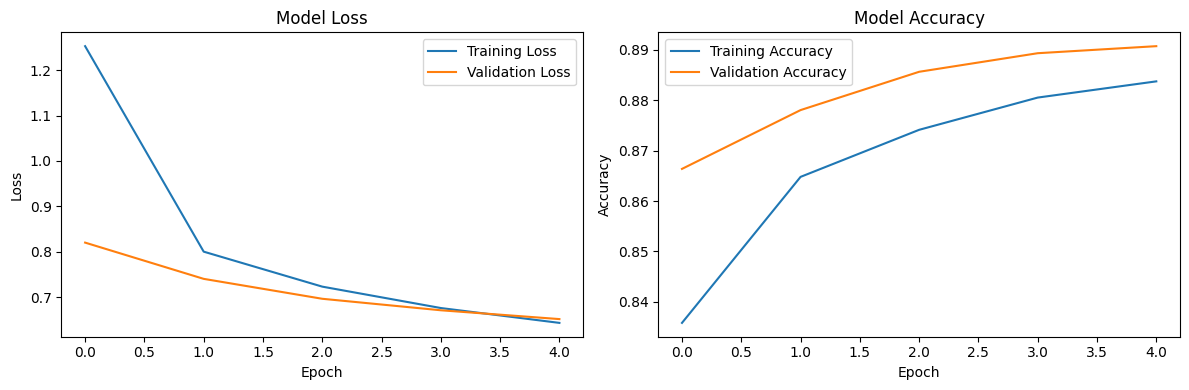

In [ ]:
# Gráfico de pérdida durante entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

El entrenamiento de este modelo de chatbot muestra relativo comportamiento en las primeras 4 épocas:
- El modelo está aprendiendo; tanto la pérdida como la precisión en los conjuntos de entrenamiento y validación muestran una mejora constante.
- Buena capacidad de generalización; la pérdida de validación disminuye y la precisión de validación aumenta junto con las métricas de entrenamiento, lo que indica que el modelo está aprendiendo patrones útiles y no simplemente memorizando los datos de entrenamiento. No hay señales claras de sobreajuste en este punto.
- Potencial para más entrenamiento; dado que ambas curvas siguen mostrando una tendencia positiva (disminución de la pérdida, aumento de la precisión), el modelo probablemente podría beneficiarse de más épocas de entrenamiento para lograr un rendimiento aún mejor. Puede mejorar el chatbot.

In [ ]:
print("\n=== ENTRENAMIENTO COMPLETADO ===")
print(f"Vocabulario de entrada: {num_words_input} palabras")
print(f"Vocabulario de salida: {num_words_output} palabras")
print(f"Longitud máxima entrada: {max_input_len}")
print(f"Longitud máxima salida: {max_output_len}")
print("Modelos guardados: encoder_model.h5, decoder_model.h5")
print("Tokenizers guardados: input_tokenizer.pkl, output_tokenizer.pkl")


=== ENTRENAMIENTO COMPLETADO ===
Vocabulario de entrada: 3611 palabras
Vocabulario de salida: 3582 palabras
Longitud máxima entrada: 40
Longitud máxima salida: 44
Modelos guardados: encoder_model.h5, decoder_model.h5
Tokenizers guardados: input_tokenizer.pkl, output_tokenizer.pkl
